# **Praktikum 1. Segmentasi Menggunakan Thresholding Global dan Otsu**

Kode pada praktikum ini bertujuan untuk melakukan proses segmentasi citra menggunakan dua pendekatan thresholding, yaitu thresholding global manual dan thresholding otomatis metode Otsu. Program diawali dengan memuat citra grayscale berupa gambar koin dari library scikit-image. Selanjutnya dilakukan thresholding global dengan menentukan nilai ambang tetap sebesar 100, sehingga piksel yang memiliki intensitas lebih tinggi dari nilai tersebut akan dianggap sebagai objek dan sisanya menjadi latar belakang. Setelah itu, program menerapkan metode Otsu yang secara otomatis menghitung nilai threshold terbaik berdasarkan penyebaran histogram intensitas piksel pada citra. Hasil dari kedua metode segmentasi tersebut kemudian divisualisasikan bersama citra asli dalam tiga panel menggunakan matplotlib agar perbedaannya dapat diamati secara langsung. Pada bagian akhir, program juga menampilkan nilai threshold yang diperoleh dari metode Otsu untuk mengetahui ambang optimal yang digunakan dalam proses segmentasi otomatis.

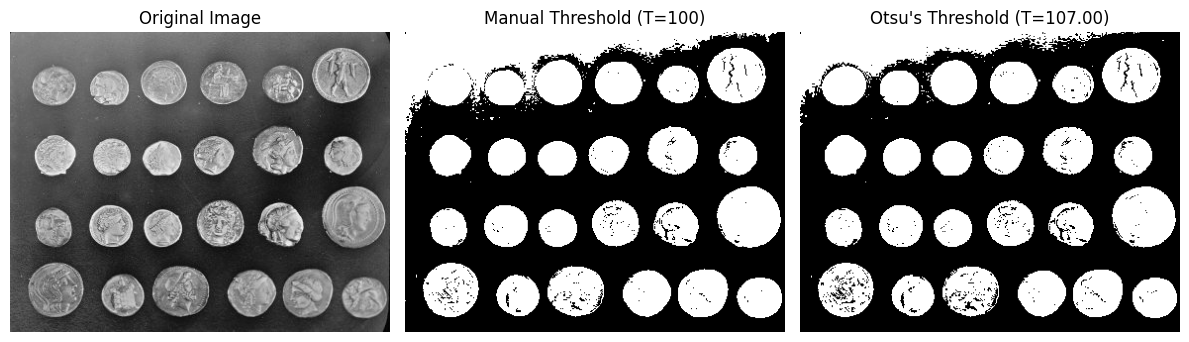

Nilai threshold Otsu yang ditemukan: 107


In [1]:
import matplotlib.pyplot as plt
from skimage import data, filters

# 1. Mengambil citra contoh dari library skimage
image_coins = data.coins()   # Gambar koin ini sudah dalam format grayscale

# 2. Melakukan thresholding global secara manual
# Menentukan nilai ambang tetap untuk memisahkan objek dan latar belakang
thresh_manual = 100
binary_manual = image_coins > thresh_manual

# 3. Melakukan thresholding otomatis dengan metode Otsu
# Sistem akan mencari nilai ambang terbaik berdasarkan distribusi intensitas piksel
thresh_otsu = filters.threshold_otsu(image_coins)
binary_otsu = image_coins > thresh_otsu

# 4. Menampilkan citra asli dan hasil segmentasi
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_manual, cmap=plt.cm.gray)
ax[1].set_title(f'Manual Threshold (T={thresh_manual})')
ax[1].axis('off')

ax[2].imshow(binary_otsu, cmap=plt.cm.gray)
ax[2].set_title(f"Otsu's Threshold (T={thresh_otsu:.2f})")
ax[2].axis('off')

plt.tight_layout()
plt.show()

# 5. Menampilkan nilai threshold hasil perhitungan Otsu
print(f"Nilai threshold Otsu yang ditemukan: {thresh_otsu}")

Hasil yang diperoleh menunjukkan bahwa kedua metode thresholding mampu memisahkan objek koin dari latar belakang menjadi citra biner berwarna hitam putih. Pada thresholding global manual, pemisahan objek bergantung pada nilai ambang yang ditentukan pengguna, sehingga apabila nilai threshold kurang sesuai maka masih ada bagian objek yang hilang atau latar belakang yang ikut tersegmentasi. Sedangkan pada metode Otsu, sistem secara otomatis menentukan nilai ambang optimal dari distribusi intensitas citra sehingga hasil segmentasi terlihat lebih adaptif dan umumnya lebih rapi dalam membedakan area koin dengan background. Dari visualisasi dapat dilihat bahwa metode Otsu memberikan pemisahan objek yang lebih konsisten dibandingkan threshold manual, sehingga metode ini lebih efektif digunakan ketika pengguna tidak mengetahui nilai threshold yang paling tepat secara langsung.

# **Praktikum 2. Segmentasi Menggunakan Region Growing (Contoh Sederhana)**

Kode pada praktikum ini bertujuan untuk melakukan segmentasi citra dengan metode region growing sederhana menggunakan algoritma flood fill. Program dimulai dengan memuat citra grayscale camera dari library scikit-image sebagai objek uji. Selanjutnya ditentukan sebuah seed point atau titik benih pada koordinat tertentu yang menjadi titik awal pertumbuhan region. Dari titik tersebut, algoritma flood fill akan memeriksa piksel-piksel di sekitarnya dan memasukkan piksel yang memiliki kemiripan intensitas berdasarkan nilai tolerance yang ditentukan, yaitu 10. Piksel-piksel yang memenuhi syarat tersebut akan dianggap sebagai bagian dari satu wilayah yang sama sehingga membentuk sebuah mask segmentasi. Setelah region ditemukan, program membuat salinan citra asli lalu menandai area hasil pertumbuhan region dengan warna putih agar lebih mudah diamati. Pada tahap akhir, seluruh proses divisualisasikan dalam tiga panel berupa citra asli dengan penanda seed point, mask region hasil flood fill, dan citra hasil segmentasi akhir.

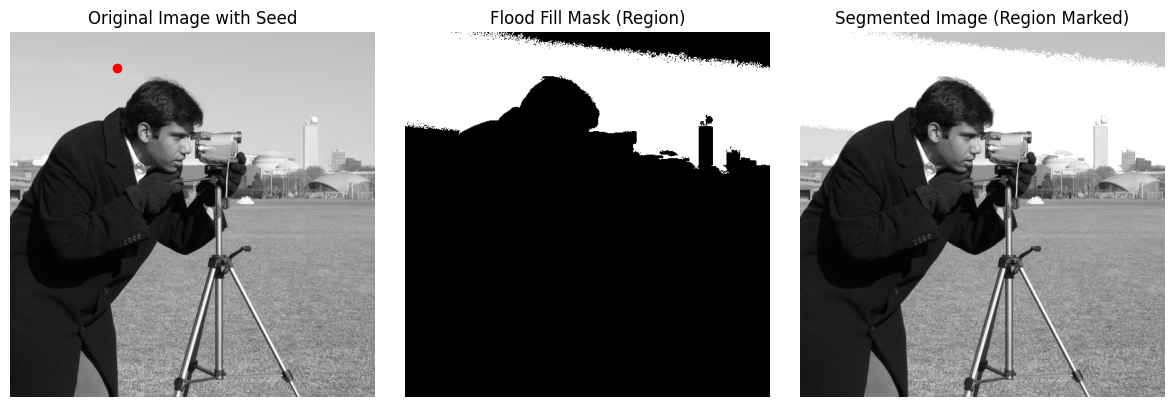

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation

# 1. Mengambil citra contoh grayscale dari library skimage
image_camera = data.camera()

# 2. Menentukan titik awal (seed point) untuk pertumbuhan region
# Titik ini dipilih pada area yang ingin dijadikan acuan segmentasi
seed_point = (50, 150)

# 3. Menjalankan algoritma flood fill sebagai simulasi region growing
# Parameter tolerance mengatur batas perbedaan intensitas piksel yang masih dianggap satu wilayah
flood_mask = segmentation.flood(image_camera, seed_point, tolerance=10)

# 4. Membuat citra hasil segmentasi
# Piksel yang termasuk region hasil pertumbuhan ditandai dengan warna putih
segmented_image = np.copy(image_camera)
segmented_image[flood_mask] = 255

# 5. Menampilkan citra asli, mask region, dan hasil segmentasi
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_camera, cmap=plt.cm.gray)
ax[0].plot(seed_point[1], seed_point[0], 'ro')
ax[0].set_title('Original Image with Seed')
ax[0].axis('off')

ax[1].imshow(flood_mask, cmap=plt.cm.gray)
ax[1].set_title('Flood Fill Mask (Region)')
ax[1].axis('off')

ax[2].imshow(segmented_image, cmap=plt.cm.gray)
ax[2].set_title('Segmented Image (Region Marked)')
ax[2].axis('off')

plt.tight_layout()
plt.show()

Hasil yang diperoleh menunjukkan bahwa metode region growing mampu menyeleksi area citra yang memiliki kemiripan intensitas dengan titik seed yang dipilih. Dimulai dari seed point pada area tertentu, algoritma akan memperluas wilayah ke piksel-piksel tetangga yang masih berada dalam batas toleransi intensitas, sehingga terbentuk sebuah region yang saling terhubung. Pada gambar mask terlihat area mana saja yang berhasil dimasukkan ke dalam region, sedangkan pada citra segmentasi akhir area tersebut ditandai putih sehingga tampak jelas bagian citra yang teridentifikasi. Keberhasilan segmentasi metode ini sangat dipengaruhi oleh pemilihan seed point dan besar nilai tolerance, karena jika seed ditempatkan pada area yang berbeda atau tolerance terlalu besar maka region yang tumbuh dapat meluas ke bagian citra lain yang tidak diinginkan.

# **Praktikum 3. Segmentasi Citra Berwarna Menggunakan K-Means Clustering**

Kode pada praktikum ini bertujuan untuk melakukan segmentasi citra berwarna dengan metode K-Means Clustering, yaitu teknik pengelompokan piksel berdasarkan kemiripan warna. Program diawali dengan memuat citra berwarna astronaut dari library scikit-image, kemudian nilai piksel diubah ke format float agar lebih mudah diproses secara numerik. Setelah itu citra dikonversi dari ruang warna RGB ke ruang warna Lab, karena ruang warna Lab lebih sesuai untuk merepresentasikan persepsi warna manusia. Seluruh piksel citra kemudian diubah menjadi data dua dimensi yang berisi kumpulan fitur warna untuk setiap piksel. Selanjutnya algoritma K-Means diterapkan dengan jumlah klaster sebanyak empat, sehingga seluruh piksel akan dikelompokkan ke dalam empat segmen warna utama. Hasil label klaster yang diperoleh kemudian dikembalikan ke bentuk dimensi citra semula. Setelah itu dibuat citra segmentasi baru dengan cara mengganti setiap piksel menggunakan warna pusat dari klaster tempat piksel tersebut berada. Tahap terakhir adalah mengonversi hasil segmentasi kembali ke RGB dan menampilkannya bersama citra asli serta peta label klaster agar proses pengelompokan warna dapat diamati dengan jelas.

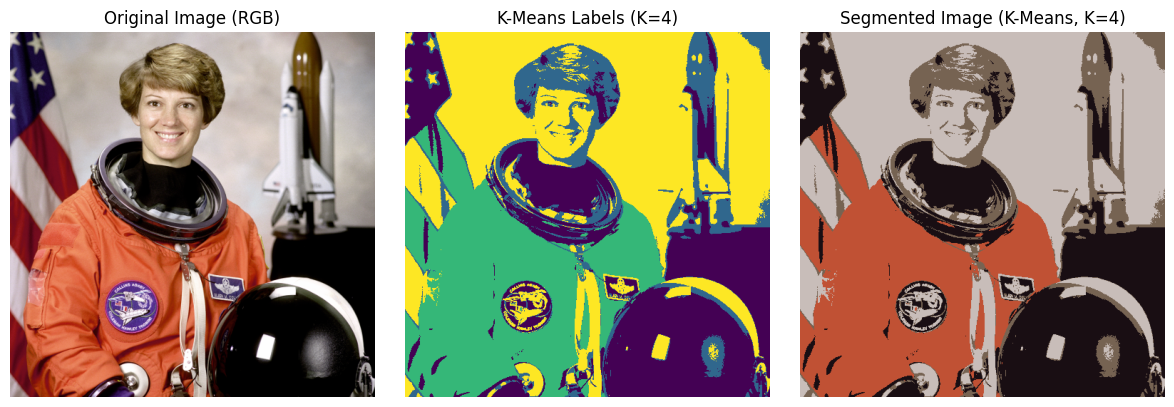

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from sklearn.cluster import KMeans
from skimage.color import rgb2lab, lab2rgb
import warnings

# 1. Mengambil citra berwarna contoh dari library skimage
image_astro = data.astronaut()

# Mengubah nilai piksel ke format float agar proses komputasi lebih stabil
image_astro_float = image_astro.astype(float) / 255.0

# 2. Mengubah citra menjadi kumpulan data piksel untuk proses clustering
# Citra dikonversi ke ruang warna Lab agar pengelompokan warna lebih representatif
image_lab = rgb2lab(image_astro_float)
rows, cols, dims = image_lab.shape
pixel_features = image_lab.reshape(rows * cols, dims)

# 3. Menjalankan algoritma K-Means Clustering
# Menentukan jumlah klaster warna yang diinginkan
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

# 4. Mengembalikan label klaster ke bentuk dimensi citra
segmented_labels = pixel_labels.reshape(rows, cols)

# 5. Membuat citra segmentasi berdasarkan warna pusat masing-masing klaster
segmented_image_kmeans = np.zeros_like(image_lab)
centers_lab = kmeans.cluster_centers_

for k in range(n_clusters):
    # Memilih piksel yang termasuk pada klaster ke-k
    cluster_pixels = (pixel_labels == k)

    # Membentuk mask sesuai ukuran citra
    mask_k = cluster_pixels.reshape(rows, cols)

    # Mengisi area mask dengan warna pusat klaster
    segmented_image_kmeans[mask_k] = centers_lab[k]

# Mengubah kembali hasil segmentasi ke ruang warna RGB
segmented_image_rgb = lab2rgb(segmented_image_kmeans)

# 6. Menampilkan citra asli, label klaster, dan hasil segmentasi
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_astro)
ax[0].set_title('Original Image (RGB)')
ax[0].axis('off')

ax[1].imshow(segmented_labels, cmap='viridis')
ax[1].set_title(f'K-Means Labels (K={n_clusters})')
ax[1].axis('off')

ax[2].imshow(segmented_image_rgb)
ax[2].set_title(f'Segmented Image (K-Means, K={n_clusters})')
ax[2].axis('off')

plt.tight_layout()
plt.show()

Hasil yang diperoleh menunjukkan bahwa metode K-Means Clustering berhasil membagi citra berwarna menjadi beberapa kelompok area berdasarkan kesamaan warna dominan. Pada tampilan label klaster, setiap warna palsu merepresentasikan kelompok piksel yang memiliki karakteristik warna serupa, sehingga bagian-bagian citra seperti wajah, pakaian, latar belakang, dan objek lain dapat terpisah menjadi segmen berbeda. Sementara itu pada citra hasil segmentasi, setiap area diwarnai menggunakan warna rata-rata dari pusat klasternya sehingga citra terlihat lebih sederhana namun tetap mempertahankan struktur objek utama. Semakin sedikit jumlah klaster yang digunakan maka hasil segmentasi akan semakin kasar, sedangkan jika jumlah klaster diperbesar maka detail pemisahan warna akan semakin banyak. Hal ini menunjukkan bahwa K-Means sangat efektif untuk segmentasi citra berwarna karena mampu mengelompokkan piksel tanpa perlu menentukan batas objek secara manual.

# **Praktikum 4. Segmentasi Berbasis Tepi Menggunakan Watershed**

Kode pada praktikum ini bertujuan untuk melakukan segmentasi citra berdasarkan tepi menggunakan algoritma Watershed. Program diawali dengan memuat citra grayscale coins dari library scikit-image. Setelah citra dimuat, dilakukan perhitungan gradien menggunakan operator Sobel untuk menghasilkan elevation map atau peta topografi, yaitu representasi perubahan intensitas piksel yang menonjolkan area tepi objek. Selanjutnya program membuat marker awal sebagai titik acuan pembanjiran, di mana piksel dengan intensitas sangat gelap ditandai sebagai latar belakang dan piksel dengan intensitas terang ditandai sebagai objek. Marker ini berfungsi sebagai sumber awal wilayah yang nantinya akan diperluas. Setelah marker tersedia, algoritma Watershed dijalankan dengan cara mensimulasikan proses aliran air pada peta gradien, sehingga area-area yang terpisah oleh tepi akan terbagi menjadi region yang berbeda. Hasil segmentasi kemudian diberi garis batas pada citra asli menggunakan mark_boundaries agar kontur pemisahan objek terlihat jelas. Seluruh tahapan tersebut divisualisasikan mulai dari citra asli, peta gradien, marker, hingga hasil akhir segmentasi Watershed.

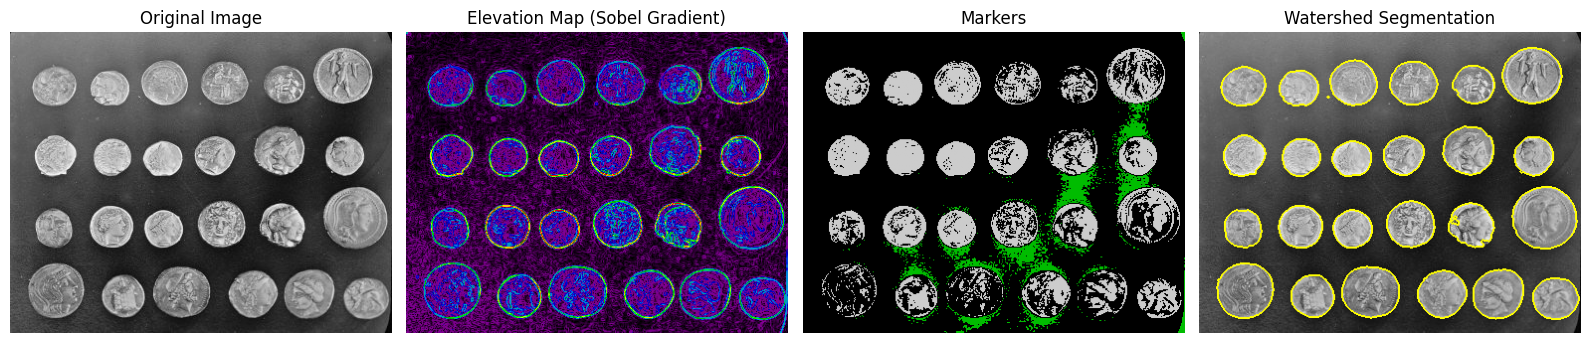

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation

# 1. Mengambil citra grayscale contoh dari library skimage
image_coins = data.coins()

# 2. Menghitung gradien citra sebagai peta topografi
# Operator Sobel digunakan untuk menonjolkan perubahan intensitas atau tepi objek
elevation_map = filters.sobel(image_coins)

# 3. Menentukan marker awal sebagai acuan pemisahan wilayah
# Nilai rendah dianggap latar belakang, nilai tinggi dianggap objek
markers = np.zeros_like(image_coins)
markers[image_coins < 30] = 1
markers[image_coins > 150] = 2

# 4. Menjalankan algoritma Watershed
# Proses ini membanjiri peta gradien dari marker yang sudah dibuat
segmentation_watershed = segmentation.watershed(elevation_map, markers)

# Memberi garis batas hasil segmentasi pada citra asli
segmented_colored = segmentation.mark_boundaries(image_coins, segmentation_watershed)

# 5. Menampilkan seluruh tahapan hasil segmentasi
fig, axes = plt.subplots(ncols=4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(elevation_map, cmap=plt.cm.nipy_spectral)
ax[1].set_title('Elevation Map (Sobel Gradient)')
ax[1].axis('off')

ax[2].imshow(markers, cmap=plt.cm.nipy_spectral)
ax[2].set_title('Markers')
ax[2].axis('off')

ax[3].imshow(segmented_colored)
ax[3].set_title('Watershed Segmentation')
ax[3].axis('off')

plt.tight_layout()
plt.show()

Hasil yang diperoleh menunjukkan bahwa metode Watershed mampu memisahkan objek-objek koin berdasarkan kontur tepinya meskipun beberapa koin saling berdekatan. Pada elevation map terlihat area tepi citra sebagai daerah dengan perubahan intensitas tinggi yang berfungsi seperti dinding pemisah. Marker yang dibuat menjadi titik awal pembentukan wilayah antara objek dan latar belakang. Ketika algoritma Watershed dijalankan, proses pembanjiran dari marker akan berhenti ketika bertemu gradien tepi yang tinggi, sehingga setiap koin dapat dipisahkan menjadi region tersendiri. Pada hasil akhir segmentasi terlihat garis batas yang mengikuti kontur masing-masing koin, menandakan bahwa objek berhasil dipisahkan dari background maupun dari objek lain di sekitarnya. Metode ini sangat efektif untuk citra yang memiliki objek saling menempel karena memanfaatkan informasi tepi sebagai batas alami segmentasi.

# **Praktikum 5. Perbandingan Visual Hasil Segmentasi**

Kode pada praktikum ini bertujuan untuk membandingkan tiga metode segmentasi citra yang berbeda pada satu citra grayscale yang sama, yaitu Otsu Thresholding, K-Means Clustering, dan Watershed. Program dimulai dengan memuat citra camera dari library scikit-image kemudian mengubahnya ke format float agar lebih mudah diproses pada beberapa metode. Langkah pertama segmentasi dilakukan menggunakan Otsu Thresholding, di mana sistem secara otomatis mencari nilai ambang terbaik untuk memisahkan objek dan latar belakang menjadi citra biner. Selanjutnya diterapkan K-Means Clustering dengan jumlah klaster tiga, di mana seluruh piksel dikelompokkan berdasarkan kemiripan intensitas sehingga menghasilkan beberapa area segmentasi dengan label berbeda. Setelah itu program menerapkan metode Watershed, dimulai dengan menghitung gradien Sobel sebagai peta tepi dan membuat marker sederhana berdasarkan hasil threshold Otsu untuk memisahkan foreground dan background. Algoritma Watershed kemudian digunakan untuk membentuk batas antarwilayah berdasarkan kontur intensitas. Pada tahap akhir, seluruh hasil segmentasi dari ketiga metode tersebut ditampilkan berdampingan bersama citra asli agar pengguna dapat melihat perbedaan karakteristik hasil segmentasi dari masing-masing pendekatan secara visual.

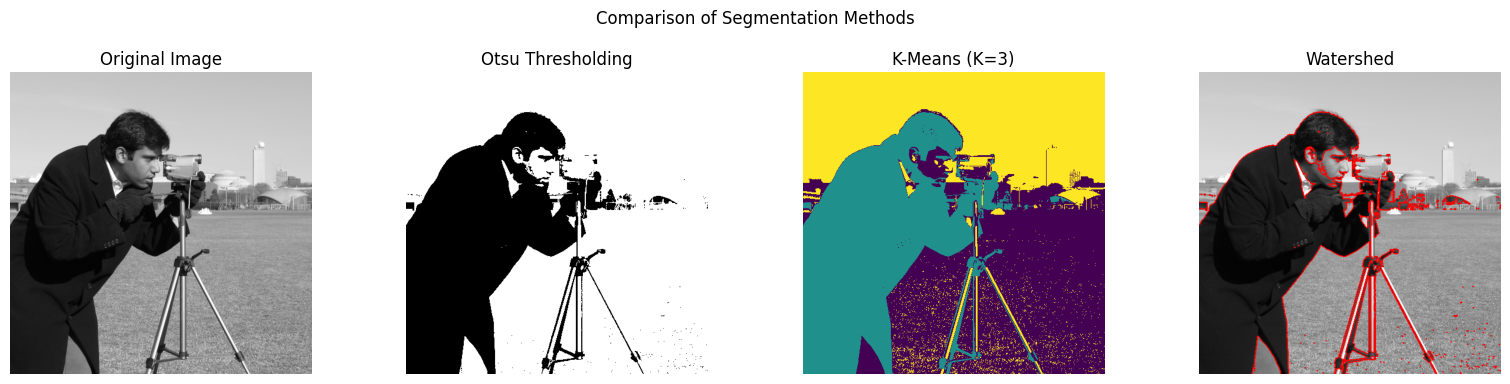

In [5]:
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, img_as_float
from sklearn.cluster import KMeans
import numpy as np
import warnings

# 1. Mengambil satu citra grayscale sebagai bahan perbandingan
image = data.camera()
image_float = img_as_float(image)

# 2. Menerapkan beberapa metode segmentasi

# a) Segmentasi dengan Otsu Thresholding
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

# b) Segmentasi dengan K-Means Clustering
# Citra diubah menjadi data satu dimensi berdasarkan intensitas piksel
rows, cols = image.shape
pixel_features = image_float.reshape(rows * cols, 1)

n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

segmented_kmeans_labels = pixel_labels.reshape(rows, cols)

# c) Segmentasi dengan Watershed
# Marker sederhana dibuat dari hasil threshold Otsu
elevation_map = filters.sobel(image)
markers = np.zeros_like(image)
markers[image < thresh_otsu] = 1
markers[image > thresh_otsu] = 2

segmentation_watershed = segmentation.watershed(elevation_map, markers)

# 3. Menampilkan hasil perbandingan semua metode
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title('Otsu Thresholding')
ax[1].axis('off')

ax[2].imshow(segmented_kmeans_labels, cmap='viridis')
ax[2].set_title(f'K-Means (K={n_clusters})')
ax[2].axis('off')

# Memberi garis batas hasil Watershed agar lebih mudah diamati
segmented_watershed_colored = segmentation.mark_boundaries(
    image_float, segmentation_watershed, color=(1, 0, 0)
)
ax[3].imshow(segmented_watershed_colored)
ax[3].set_title('Watershed')
ax[3].axis('off')

plt.suptitle('Comparison of Segmentation Methods')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Hasil yang diperoleh menunjukkan bahwa setiap metode segmentasi memiliki karakteristik pemisahan citra yang berbeda. Otsu Thresholding menghasilkan segmentasi biner sederhana yang hanya memisahkan area terang dan gelap berdasarkan satu nilai ambang global, sehingga cocok untuk citra dengan kontras jelas tetapi kurang detail pada area kompleks. K-Means Clustering menghasilkan beberapa kelompok wilayah berdasarkan kemiripan intensitas piksel, sehingga citra terbagi menjadi beberapa segmen bertingkat yang menunjukkan variasi area dengan lebih halus dibanding threshold biasa. Sementara itu metode Watershed menampilkan garis batas kontur yang mengikuti perubahan intensitas dan tepi objek, sehingga lebih menonjolkan pemisahan bentuk antarwilayah. Dari perbandingan visual ini dapat disimpulkan bahwa Otsu lebih sederhana dan cepat, K-Means lebih baik untuk pengelompokan area berdasarkan kesamaan nilai piksel, sedangkan Watershed lebih unggul dalam mendeteksi batas objek. Oleh karena itu, pemilihan metode segmentasi sangat bergantung pada jenis citra dan tujuan analisis yang ingin dicapai.

# **Eksperimen Thresholding pada Citra data.page()**

Kode pada praktikum ini bertujuan untuk menguji dan membandingkan beberapa metode thresholding pada citra dokumen data.page() yang berisi teks hasil pemindaian. Program diawali dengan memuat citra grayscale halaman dokumen dari library scikit-image. Selanjutnya dilakukan segmentasi pertama menggunakan metode Otsu Thresholding, yaitu threshold global yang mencari satu nilai ambang terbaik berdasarkan distribusi histogram seluruh citra. Setelah itu program menerapkan metode Yen Thresholding yang juga termasuk threshold global, tetapi menggunakan pendekatan perhitungan histogram yang berbeda untuk menentukan nilai ambang. Kemudian diterapkan threshold_local, yaitu metode adaptive thresholding yang menghitung nilai ambang secara lokal pada setiap blok area citra sehingga lebih mampu menyesuaikan perubahan pencahayaan. Ketiga hasil thresholding tersebut lalu divisualisasikan bersama citra asli dalam empat panel agar perbedaan kualitas segmentasi dapat diamati secara langsung.

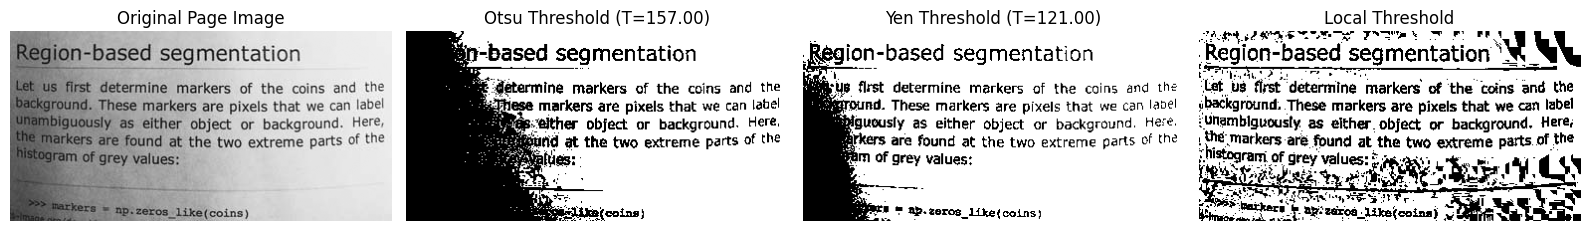

In [6]:
import matplotlib.pyplot as plt
from skimage import data, filters

# 1. Mengambil citra dokumen dari library skimage
image_page = data.page()

# 2. Segmentasi menggunakan Otsu Thresholding
# Metode ini mencari satu nilai ambang global untuk seluruh citra
thresh_otsu = filters.threshold_otsu(image_page)
binary_otsu = image_page > thresh_otsu

# 3. Segmentasi menggunakan Yen Thresholding
# Yen juga termasuk threshold global tetapi menggunakan pendekatan histogram berbeda
thresh_yen = filters.threshold_yen(image_page)
binary_yen = image_page > thresh_yen

# 4. Segmentasi menggunakan Local Thresholding
# Setiap area citra memiliki nilai ambang masing-masing menyesuaikan pencahayaan lokal
local_thresh = filters.threshold_local(image_page, block_size=35)
binary_local = image_page > local_thresh

# 5. Menampilkan hasil perbandingan ketiga metode
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
ax = axes.ravel()

ax[0].imshow(image_page, cmap=plt.cm.gray)
ax[0].set_title('Original Page Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title(f'Otsu Threshold (T={thresh_otsu:.2f})')
ax[1].axis('off')

ax[2].imshow(binary_yen, cmap=plt.cm.gray)
ax[2].set_title(f'Yen Threshold (T={thresh_yen:.2f})')
ax[2].axis('off')

ax[3].imshow(binary_local, cmap=plt.cm.gray)
ax[3].set_title('Local Threshold')
ax[3].axis('off')

plt.tight_layout()
plt.show()

Hasil yang diperoleh menunjukkan bahwa Otsu Thresholding pada citra data.page() belum sepenuhnya memuaskan. Hal ini disebabkan karena Otsu hanya menggunakan satu nilai ambang global untuk seluruh gambar, sedangkan citra dokumen memiliki variasi pencahayaan, bayangan, dan ketebalan teks yang tidak merata. Akibatnya pada beberapa bagian teks terlihat kurang tajam atau ada area latar belakang yang masih ikut terbaca sebagai objek. Metode Yen Thresholding memberikan hasil yang sedikit berbeda, namun karena masih sama-sama menggunakan threshold global maka masalah ketidakseragaman pencahayaan belum sepenuhnya teratasi. Sementara itu threshold_local menghasilkan segmentasi yang lebih baik karena setiap area citra dihitung nilai ambangnya sendiri sesuai kondisi intensitas di wilayah tersebut. Teks pada dokumen menjadi lebih jelas, kontras huruf lebih tajam, dan background yang tidak rata dapat dipisahkan dengan lebih efektif. Dari eksperimen ini dapat disimpulkan bahwa untuk citra dokumen yang memiliki pencahayaan tidak seragam, adaptive thresholding seperti threshold_local lebih unggul dibandingkan metode global seperti Otsu maupun Yen.

# **Perbandingan Tiga Metode Segmentasi pada Dua Citra Upload**

Kode pada praktikum ini bertujuan untuk membandingkan performa tiga metode segmentasi citra pada dua gambar yang diunggah pengguna secara langsung. Program dimulai dengan meminta pengguna mengupload dua file gambar dari komputer, sehingga citra yang digunakan dapat berupa gambar buah, objek sederhana, sel mikroskop, atau citra lain yang memiliki latar cukup jelas. Setelah file dibaca, gambar RGB diubah ke grayscale untuk keperluan metode tertentu. Selanjutnya program menyiapkan tiga fungsi segmentasi yang berbeda. Fungsi pertama adalah Otsu Thresholding yang memisahkan objek dan latar belakang menggunakan satu nilai ambang global. Fungsi kedua adalah K-Means Clustering yang mengelompokkan piksel berdasarkan kemiripan warna menjadi tiga klaster utama. Fungsi ketiga adalah Watershed yang memanfaatkan gradien tepi dan marker untuk membentuk batas antarobjek. Ketiga metode tersebut diterapkan pada gambar pertama dan gambar kedua secara terpisah. Setelah semua hasil diperoleh, program menampilkan dua set visualisasi, di mana masing-masing gambar akan diperlihatkan dalam empat panel yaitu citra asli, hasil Otsu, hasil K-Means, dan hasil Watershed sehingga pengguna dapat melakukan analisis visual secara langsung terhadap kualitas segmentasi pada kedua citra.

Upload gambar pertama


Saving buah-buahan.jpeg to buah-buahan.jpeg
Upload gambar kedua


Saving Screenshot from 2026-04-27 17-10-01.png to Screenshot from 2026-04-27 17-10-01.png


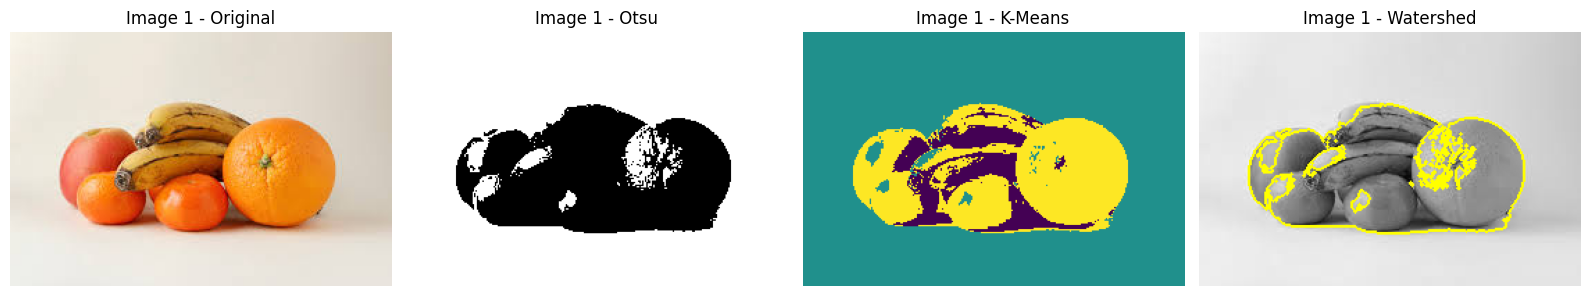

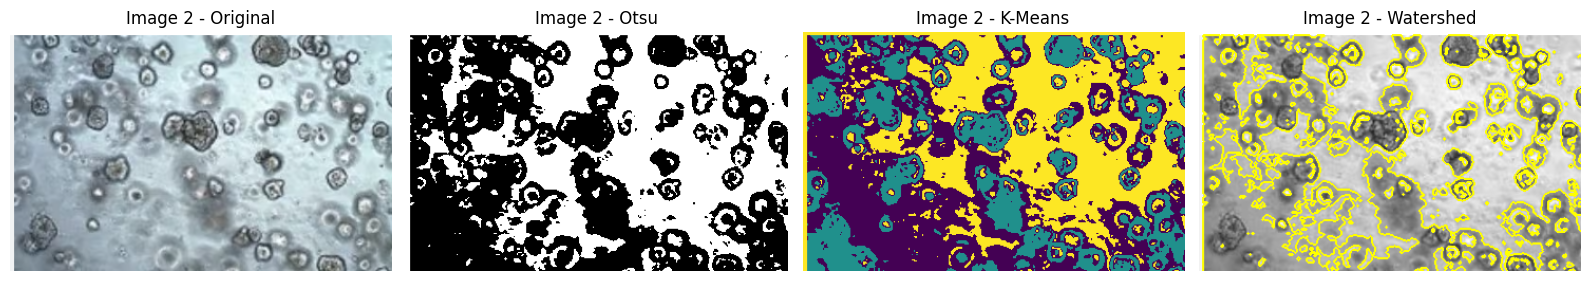

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from skimage import io, color, filters, segmentation, img_as_float
from google.colab import files
import warnings

# =========================================================
# 1. Upload dua file citra dari komputer
# =========================================================
print("Upload gambar pertama")
uploaded1 = files.upload()

print("Upload gambar kedua")
uploaded2 = files.upload()

# Ambil nama file yang diupload
file1 = list(uploaded1.keys())[0]
file2 = list(uploaded2.keys())[0]

# Baca gambar
img1_rgb = io.imread(file1)
img2_rgb = io.imread(file2)

# Jika gambar memiliki alpha channel, buang channel transparansi
if img1_rgb.shape[-1] == 4:
    img1_rgb = img1_rgb[:, :, :3]

if img2_rgb.shape[-1] == 4:
    img2_rgb = img2_rgb[:, :, :3]

# Ubah ke grayscale untuk beberapa metode
img1_gray = color.rgb2gray(img1_rgb)
img2_gray = color.rgb2gray(img2_rgb)

# =========================================================
# FUNGSI SEGMENTASI OTSU
# =========================================================
def otsu_segmentation(gray_img):
    thresh = filters.threshold_otsu(gray_img)
    binary = gray_img > thresh
    return binary

# =========================================================
# FUNGSI SEGMENTASI K-MEANS
# =========================================================
def kmeans_segmentation(rgb_img, n_clusters=3):
    image_float = img_as_float(rgb_img)
    rows, cols, dims = image_float.shape
    pixels = image_float.reshape(rows * cols, dims)

    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        labels = kmeans.fit_predict(pixels)

    segmented = labels.reshape(rows, cols)
    return segmented

# =========================================================
# FUNGSI SEGMENTASI WATERSHED
# =========================================================
def watershed_segmentation(gray_img):
    elevation_map = filters.sobel(gray_img)

    thresh = filters.threshold_otsu(gray_img)
    markers = np.zeros_like(gray_img, dtype=np.uint8)
    markers[gray_img < thresh] = 1
    markers[gray_img > thresh] = 2

    ws = segmentation.watershed(elevation_map, markers)
    ws_boundaries = segmentation.mark_boundaries(gray_img, ws)
    return ws_boundaries

# =========================================================
# PROSES SEMUA METODE UNTUK GAMBAR 1
# =========================================================
img1_otsu = otsu_segmentation(img1_gray)
img1_kmeans = kmeans_segmentation(img1_rgb, n_clusters=3)
img1_watershed = watershed_segmentation(img1_gray)

# =========================================================
# PROSES SEMUA METODE UNTUK GAMBAR 2
# =========================================================
img2_otsu = otsu_segmentation(img2_gray)
img2_kmeans = kmeans_segmentation(img2_rgb, n_clusters=3)
img2_watershed = watershed_segmentation(img2_gray)

# =========================================================
# VISUALISASI HASIL GAMBAR 1
# =========================================================
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
ax = axes.ravel()

ax[0].imshow(img1_rgb)
ax[0].set_title('Image 1 - Original')
ax[0].axis('off')

ax[1].imshow(img1_otsu, cmap='gray')
ax[1].set_title('Image 1 - Otsu')
ax[1].axis('off')

ax[2].imshow(img1_kmeans, cmap='viridis')
ax[2].set_title('Image 1 - K-Means')
ax[2].axis('off')

ax[3].imshow(img1_watershed)
ax[3].set_title('Image 1 - Watershed')
ax[3].axis('off')

plt.tight_layout()
plt.show()

# =========================================================
# VISUALISASI HASIL GAMBAR 2
# =========================================================
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
ax = axes.ravel()

ax[0].imshow(img2_rgb)
ax[0].set_title('Image 2 - Original')
ax[0].axis('off')

ax[1].imshow(img2_otsu, cmap='gray')
ax[1].set_title('Image 2 - Otsu')
ax[1].axis('off')

ax[2].imshow(img2_kmeans, cmap='viridis')
ax[2].set_title('Image 2 - K-Means')
ax[2].axis('off')

ax[3].imshow(img2_watershed)
ax[3].set_title('Image 2 - Watershed')
ax[3].axis('off')

plt.tight_layout()
plt.show()

Hasil yang diperoleh dari dua citra uji menunjukkan bahwa performa masing-masing metode segmentasi sangat dipengaruhi oleh karakteristik visual citra yang digunakan.

Pada citra pertama yaitu gambar buah-buahan dengan latar belakang polos, metode Otsu Thresholding mampu memisahkan objek buah dari background dengan cukup jelas karena citra memiliki kontras yang tinggi antara objek berwarna gelap/oranye dengan latar terang. Hasil Otsu menghasilkan siluet objek yang cukup utuh meskipun beberapa detail permukaan buah hilang karena hanya berbasis pemisahan intensitas terang dan gelap. Metode K-Means memberikan hasil yang lebih detail karena tidak hanya memisahkan objek dan background, tetapi juga mengelompokkan warna-warna berbeda pada buah seperti kuning pisang, oranye jeruk, dan bayangan latar. Dengan demikian struktur warna pada objek masih dapat terlihat. Sementara itu Watershed berhasil menampilkan garis kontur tepi objek dengan cukup baik, namun hasilnya lebih berfokus pada batas luar buah dan tidak terlalu menonjolkan isi area objek. Berdasarkan perbandingan visual tersebut, metode yang paling cocok untuk citra pertama adalah K-Means Clustering karena gambar buah memiliki informasi warna yang dominan dan metode ini mampu memanfaatkan perbedaan warna untuk menghasilkan segmentasi yang lebih kaya serta lebih representatif terhadap bentuk masing-masing buah.

Pada citra kedua yaitu gambar mikroskopis sel, kondisi citra jauh lebih kompleks karena memiliki tekstur padat, banyak objek kecil, serta kontras yang tidak seragam. Metode Otsu Thresholding pada citra ini menghasilkan segmentasi yang kurang memuaskan karena banyak area background ikut terbaca sebagai objek hitam dan beberapa sel kecil menyatu, sehingga pemisahan tidak bersih. K-Means Clustering memberikan hasil lebih informatif karena area sel, latar cairan, dan bayangan dapat dikelompokkan menjadi beberapa region intensitas berbeda, sehingga distribusi sel lebih mudah diamati walaupun masih terdapat noise. Sedangkan Watershed menghasilkan banyak garis batas kontur di sekitar sel-sel mikroskopis, sehingga bentuk tiap sel terlihat lebih jelas dibanding metode lain, meskipun muncul cukup banyak garis kecil akibat detail tekstur yang tinggi. Untuk citra kedua, metode yang paling cocok adalah Watershed karena tujuan segmentasi citra mikroskop biasanya adalah memisahkan batas antar sel, dan Watershed sangat efektif dalam menonjolkan kontur objek-objek kecil yang saling berdekatan.

Dari kedua percobaan tersebut dapat disimpulkan bahwa tidak ada satu metode segmentasi yang selalu terbaik untuk semua jenis citra. K-Means lebih unggul pada citra dengan variasi warna yang jelas karena mampu mengelompokkan piksel berdasarkan kemiripan warna, sedangkan Watershed lebih unggul pada citra tekstur kompleks yang membutuhkan deteksi batas objek secara detail. Otsu Thresholding merupakan metode paling sederhana dan cepat, namun performanya sangat bergantung pada kejelasan kontras global citra sehingga kurang adaptif pada gambar yang kompleks.
